In [33]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [34]:
corpus = """
My name is Vivek and I am passionate about Data Science and Artificial Intelligence.
I enjoy analyzing data, discovering patterns, and building machine learning solutions.
Over the past few months, I have worked on projects involving data visualization, predictive analytics, and deep learning.

Machine learning enables computers to learn from data without being explicitly programmed.
Deep learning models are capable of solving complex problems in image classification, speech recognition, and natural language processing.
Convolutional neural networks are commonly used in computer vision tasks, while recurrent neural networks are designed for sequential data.

I regularly use Python along with libraries such as Pandas, NumPy, Matplotlib, Scikit-learn, TensorFlow, and Keras.
These tools help me preprocess data, train models, evaluate performance, and deploy solutions.

Apart from technical skills, I enjoy learning about different cultures, traveling to new places, and exploring interesting technologies.
I believe continuous learning and practical experience are essential for becoming a successful machine learning engineer.

In the future, I would like to work on large-scale AI systems that solve real-world problems in healthcare, education, and business.
My goal is to develop innovative solutions that create meaningful impact through technology.
"""
print(corpus)


My name is Vivek and I am passionate about Data Science and Artificial Intelligence.
I enjoy analyzing data, discovering patterns, and building machine learning solutions.
Over the past few months, I have worked on projects involving data visualization, predictive analytics, and deep learning.

Machine learning enables computers to learn from data without being explicitly programmed.
Deep learning models are capable of solving complex problems in image classification, speech recognition, and natural language processing.
Convolutional neural networks are commonly used in computer vision tasks, while recurrent neural networks are designed for sequential data.

I regularly use Python along with libraries such as Pandas, NumPy, Matplotlib, Scikit-learn, TensorFlow, and Keras.
These tools help me preprocess data, train models, evaluate performance, and deploy solutions.

Apart from technical skills, I enjoy learning about different cultures, traveling to new places, and exploring interesti

#Tokenization & Sequence Creation
Converts text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [35]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 139
X shape: (180, 22)
y shape: (180,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [36]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [37]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [38]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


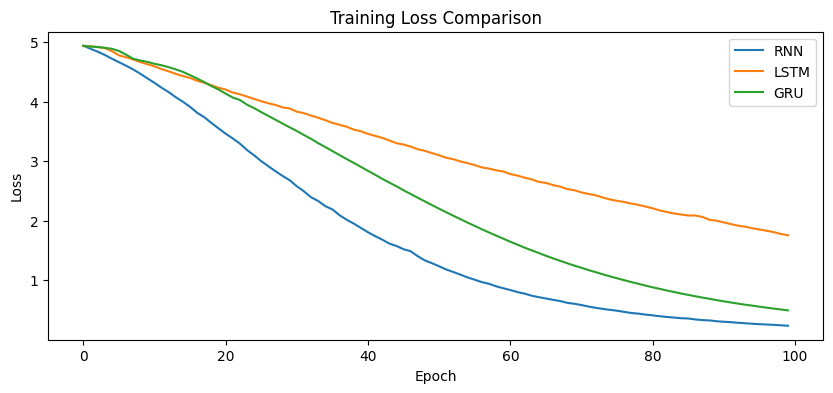

In [39]:
##Compare Training Loss

plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

In [40]:
### Text Generation Function
### This function predicts the next word repeatedly to generate a sentence.


def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text



In [41]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning models are capable of solving
LSTM: deep learning learning are are of solving
GRU : deep learning models are capable of solving


# 🧠 Improved Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [42]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Imporved Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [43]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Improved Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [44]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

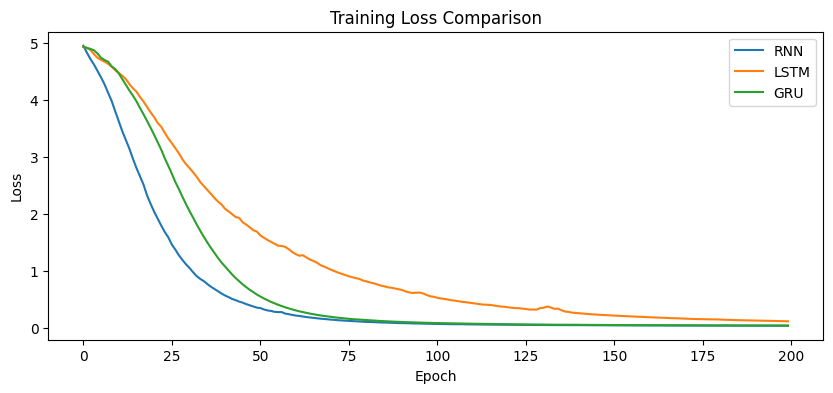

In [45]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [46]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

In [47]:
### GENERATING TEXT SAMPLES


print("RNN :", generate_text(rnn_model, "deep learning", 10))
print("LSTM:", generate_text(lstm_model, "deep learning", 10))
print("GRU :", generate_text(gru_model, "deep learning", 10))

RNN : deep learning models are capable of solving complex problems in image classification
LSTM: deep learning models are capable of solving complex problems in image classification
GRU : deep learning models are capable of solving complex problems in image classification


OBSERVATION


After increasing the embedding dimension, hidden units, and training epochs, the models generated more coherent and meaningful text. LSTM and GRU demonstrated better contextual learning compared to Vanilla RNN. All models were able to learn sentence structure and generate relevant text from the custom corpus.